[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Laverde97/phd-data-science-ai/blob/main/semesters/semester-01/machine-learning/notes/notebooks/04-arbol-decision-clasificacion.ipynb)


# Machine Learning: Árbol de Decisión para Clasificación

## Colab completo con definiciones claras, datos reales, métricas, gráficos, optimización y predicciones

### Objetivo general

Aprender a construir, evaluar e interpretar un **Árbol de Decisión para Clasificación** utilizando un conjunto de datos real.

### Al finalizar este notebook podrás:

1. Entender qué es un problema de clasificación.
2. Diferenciar clasificación de regresión.
3. Comprender cómo funciona un Árbol de Decisión para Clasificación.
4. Entender los criterios **Gini** y **Entropía**.
5. Trabajar con un dataset real.
6. Separar correctamente Train y Test usando `stratify`.
7. Entrenar un `DecisionTreeClassifier`.
8. Evaluar el modelo con:
   - Accuracy
   - Precision
   - Recall / Sensibilidad
   - Especificidad
   - F1-score
   - ROC-AUC
9. Interpretar una matriz de confusión.
10. Analizar falsos positivos y falsos negativos.
11. Detectar underfitting y overfitting.
12. Optimizar hiperparámetros con `GridSearchCV`.
13. Realizar predicciones concretas.
14. Obtener probabilidades mediante `predict_proba()`.
15. Analizar importancia de variables.
16. Visualizar el Árbol de Decisión.

> **Nota:** este ejercicio es académico. Aunque el dataset tiene contexto médico, el modelo no debe utilizarse para diagnóstico ni toma de decisiones clínicas reales.



# 1. ¿Qué es un problema de clasificación?

La **clasificación** se utiliza cuando la variable objetivo pertenece a una categoría o clase.

Ejemplos:

| Problema | Variables X | Variable y |
|---|---|---|
| Correo electrónico | texto, remitente, enlaces | spam / no spam |
| Crédito | ingresos, deuda, historial | aprueba / no aprueba |
| Fraude | monto, ubicación, comportamiento | fraude / no fraude |
| Salud | variables clínicas | positivo / negativo |
| Clientes | comportamiento | abandona / no abandona |

En clasificación queremos responder:

> **¿A qué clase pertenece esta observación?**



# 2. Clasificación vs Regresión

## Regresión

La variable objetivo es numérica.

Ejemplos:

- precio = 350000
- ventas = 1250
- consumo = 82.4

## Clasificación

La variable objetivo es categórica.

Ejemplos:

- benigno / maligno
- fraude / no fraude
- sí / no

El algoritmo puede devolver:

1. una **clase predicha**;
2. una **probabilidad de pertenecer a cada clase**.



# 3. ¿Qué es un Árbol de Decisión para Clasificación?

Un Árbol de Decisión crea reglas sucesivas para separar las observaciones en grupos cada vez más homogéneos.

Ejemplo conceptual:

`¿mean radius <= 15.4?`

Dependiendo de la respuesta, la observación sigue una rama distinta.

Al final llega a una **hoja**, donde el árbol asigna una clase.

## Componentes

- **Nodo raíz:** primera división.
- **Nodo interno:** nueva regla.
- **Rama:** resultado de una regla.
- **Hoja:** predicción final.

## ¿Qué busca el árbol?

Crear divisiones donde las clases queden lo más separadas posible.



# 4. Criterios de división: Gini y Entropía

Los árboles necesitan medir qué tan mezcladas están las clases dentro de un nodo.

## Gini

La impureza Gini es baja cuando la mayoría de las observaciones de un nodo pertenecen a la misma clase.

- Gini = 0 → nodo puro.
- Gini alto → clases mezcladas.

## Entropía

Mide incertidumbre.

También disminuye cuando un nodo se vuelve más puro.

### ¿Cuál utilizar?

En muchos problemas ambos producen resultados similares.

- `criterion="gini"` suele ser rápido y es el valor por defecto.
- `criterion="entropy"` utiliza ganancia de información.

Lo correcto es probarlos mediante validación.



# 5. Dataset real: Breast Cancer Wisconsin

Usaremos `load_breast_cancer` de scikit-learn.

Contiene:

- **569 observaciones**
- **30 variables predictoras**
- dos clases:
  - `malignant`
  - `benign`

Cada observación contiene características calculadas a partir de imágenes digitalizadas de una masa mamaria.

> Este dataset es adecuado para aprender clasificación, pero no debe interpretarse como una herramienta clínica.


In [1]:

# Librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import (
    train_test_split,
    KFold,
    StratifiedKFold,
    cross_validate,
    GridSearchCV
)
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    classification_report,
    precision_recall_curve,
    average_precision_score
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


In [2]:

# Cargar dataset
data = load_breast_cancer(as_frame=True)

X = data.data.copy()
y = data.target.copy()

df = X.copy()
df["target"] = y

print("Dimensiones:", df.shape)
print("\nClases:")
print(dict(enumerate(data.target_names)))

display(df.head())


Dimensiones: (569, 31)

Clases:
{0: np.str_('malignant'), 1: np.str_('benign')}


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0



# 6. Exploración inicial — EDA

Antes de entrenar debemos revisar:

1. dimensiones;
2. tipos de variables;
3. valores faltantes;
4. distribución de las clases;
5. posible desbalance.


In [3]:

print("Tipos de variables:")
display(df.dtypes.to_frame("dtype").head())

print("\nValores faltantes totales:")
print(df.isna().sum().sum())

print("\nResumen estadístico:")
display(df.describe().T.head(10))


Tipos de variables:


,dtype
mean radius,float64
mean texture,float64
mean perimeter,float64
mean area,float64
mean smoothness,float64



Valores faltantes totales:
0

Resumen estadístico:


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.98100,11.70000,13.37000,15.78000,28.11000
mean texture,569.0,19.289649,4.301036,9.71000,16.17000,18.84000,21.80000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.79000,75.17000,86.24000,104.10000,188.50000
mean area,569.0,654.889104,351.914129,143.50000,420.30000,551.10000,782.70000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.05263,0.08637,0.09587,0.10530,0.16340
mean compactness,569.0,0.104341,0.052813,0.01938,0.06492,0.09263,0.13040,0.34540
mean concavity,569.0,0.088799,0.079720,0.00000,0.02956,0.06154,0.13070,0.42680
mean concave points,569.0,0.048919,0.038803,0.00000,0.02031,0.03350,0.07400,0.20120
mean symmetry,569.0,0.181162,0.027414,0.10600,0.16190,0.17920,0.19570,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.04996,0.05770,0.06154,0.06612,0.09744


In [4]:

# Distribución de clases
conteo_clases = y.value_counts().sort_index()

tabla_clases = pd.DataFrame({
    "Clase": [data.target_names[i] for i in conteo_clases.index],
    "Cantidad": conteo_clases.values,
    "Porcentaje": conteo_clases.values / len(y) * 100
})

display(tabla_clases.round(2))


,Clase,Cantidad,Porcentaje
0,malignant,212,37.26
1,benign,357,62.74


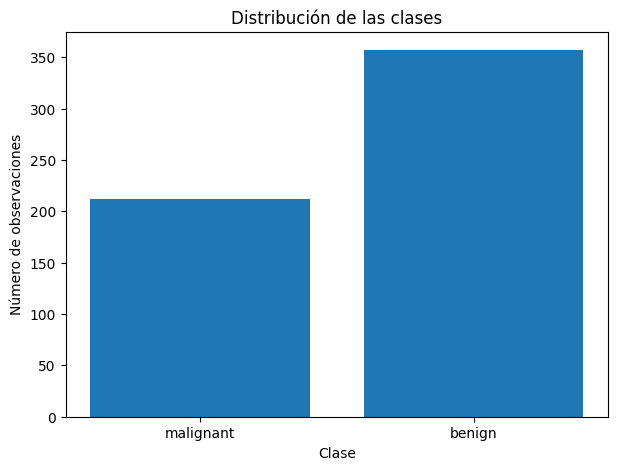

In [5]:

plt.figure(figsize=(7,5))
plt.bar(
    tabla_clases["Clase"],
    tabla_clases["Cantidad"]
)
plt.title("Distribución de las clases")
plt.xlabel("Clase")
plt.ylabel("Número de observaciones")
plt.show()



# 7. ¿Por qué importa el balance de clases?

Si una clase es mucho más frecuente que la otra, **accuracy** puede resultar engañosa.

Ejemplo:

Si 95% de los casos fueran negativos, un modelo que siempre predice negativo tendría:

**95% de accuracy**

pero sería inútil para detectar positivos.

Por eso en clasificación debemos analizar varias métricas.



# 8. Separación Train/Test con stratify

En clasificación es recomendable utilizar:

`stratify=y`

Esto conserva aproximadamente la misma proporción de clases en Train y Test.


In [6]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)

print("\nDistribución Train:")
print(y_train.value_counts(normalize=True).sort_index())

print("\nDistribución Test:")
print(y_test.value_counts(normalize=True).sort_index())


Train: (455, 30)
Test : (114, 30)

Distribución Train:
target
0    0.373626
1    0.626374
Name: proportion, dtype: float64

Distribución Test:
target
0    0.368421
1    0.631579
Name: proportion, dtype: float64



# 9. Primer Árbol de Decisión — Baseline

Comenzaremos con un árbol controlado:

- `criterion="gini"`
- `max_depth=4`
- `min_samples_leaf=5`

La idea es evitar un árbol excesivamente complejo.


In [7]:

modelo_baseline = DecisionTreeClassifier(
    criterion="gini",
    max_depth=4,
    min_samples_leaf=5,
    random_state=RANDOM_STATE
)

modelo_baseline.fit(X_train, y_train)

pred_train_baseline = modelo_baseline.predict(X_train)
pred_test_baseline = modelo_baseline.predict(X_test)

proba_test_baseline = modelo_baseline.predict_proba(X_test)[:, 1]



# 10. Matriz de confusión

Para clasificación binaria tenemos cuatro resultados posibles:

| | Predicho Positivo | Predicho Negativo |
|---|---|---|
| Real Positivo | TP | FN |
| Real Negativo | FP | TN |

## TP — True Positive
El modelo predice positivo y realmente era positivo.

## TN — True Negative
Predice negativo y realmente era negativo.

## FP — False Positive
Predice positivo, pero realmente era negativo.

## FN — False Negative
Predice negativo, pero realmente era positivo.

Los FP y FN tienen costos diferentes según el problema.


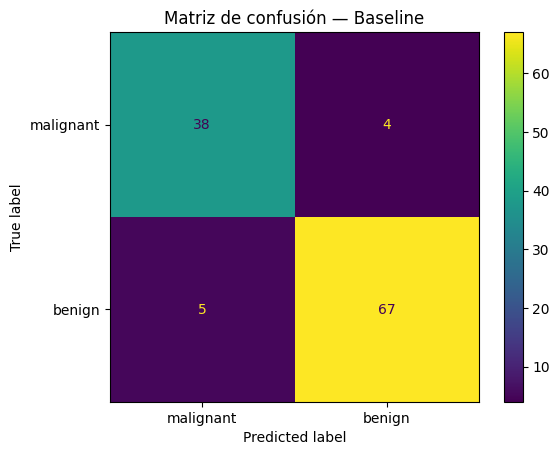

In [8]:

cm = confusion_matrix(y_test, pred_test_baseline)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=data.target_names
)

disp.plot()
plt.title("Matriz de confusión — Baseline")
plt.show()



# 11. Métricas de clasificación

## Accuracy

$$
Accuracy = \frac{TP + TN}{TP + TN + FP + FN}
$$

Indica el porcentaje total de predicciones correctas.

### Útil cuando:
- las clases están relativamente balanceadas;
- FP y FN tienen costos similares.

---

## Precision

$$
Precision = \frac{TP}{TP + FP}
$$

Pregunta:

> De todos los positivos predichos, ¿cuántos fueron realmente positivos?

### Importante cuando:
los falsos positivos son costosos.

---

## Recall / Sensibilidad

$$
Recall = \frac{TP}{TP + FN}
$$

Pregunta:

> De todos los positivos reales, ¿cuántos logró detectar el modelo?

### Importante cuando:
los falsos negativos son costosos.

---

## Especificidad

$$
Specificity = \frac{TN}{TN + FP}
$$

Pregunta:

> De todos los negativos reales, ¿cuántos identificó correctamente?

---

## F1-score

Combina Precision y Recall mediante una media armónica.

$$
F1 = 2 \times \frac{Precision \times Recall}{Precision + Recall}
$$

Es útil cuando queremos equilibrio entre ambas.

---

## ROC-AUC

Mide la capacidad del modelo para separar las clases a través de diferentes umbrales.

- 1.0 → separación perfecta.
- 0.5 → similar al azar.


In [9]:

def metricas_clasificacion(y_true, y_pred, y_proba=None):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    especificidad = tn / (tn + fp)

    resultado = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "Specificity": especificidad,
        "F1": f1_score(y_true, y_pred)
    }

    if y_proba is not None:
        resultado["ROC_AUC"] = roc_auc_score(y_true, y_proba)

    return resultado


In [10]:

metricas_train_baseline = metricas_clasificacion(
    y_train,
    pred_train_baseline,
    modelo_baseline.predict_proba(X_train)[:, 1]
)

metricas_test_baseline = metricas_clasificacion(
    y_test,
    pred_test_baseline,
    proba_test_baseline
)

tabla_baseline = pd.DataFrame({
    "Train": metricas_train_baseline,
    "Test": metricas_test_baseline
}).T

display(tabla_baseline.round(4))


,Accuracy,Precision,Recall,Specificity,F1,ROC_AUC
Train,0.9758,0.9757,0.9860,0.9588,0.9808,0.9954
Test,0.9211,0.9437,0.9306,0.9048,0.9371,0.9263


In [11]:

print(classification_report(
    y_test,
    pred_test_baseline,
    target_names=data.target_names
))


              precision    recall  f1-score   support

   malignant       0.88      0.90      0.89        42
      benign       0.94      0.93      0.94        72

    accuracy                           0.92       114
   macro avg       0.91      0.92      0.92       114
weighted avg       0.92      0.92      0.92       114




# 12. ¿Qué métrica es más importante?

No existe una métrica universalmente mejor.

## Si FP es muy costoso
Priorizar **Precision**.

## Si FN es muy costoso
Priorizar **Recall / Sensibilidad**.

## Si ambas clases importan
Usar **F1** y matriz de confusión.

## Si queremos evaluar separación global
Usar **ROC-AUC**.

En un problema médico de detección, los falsos negativos suelen merecer una atención especial, pero la decisión depende del contexto clínico real.



# 13. Underfitting y Overfitting

## Underfitting

El árbol es demasiado simple.

Señales:
- Train bajo;
- Test bajo.

## Overfitting

El árbol memoriza Train.

Señales:
- Accuracy Train cercana a 1;
- Test claramente inferior;
- árbol demasiado profundo.


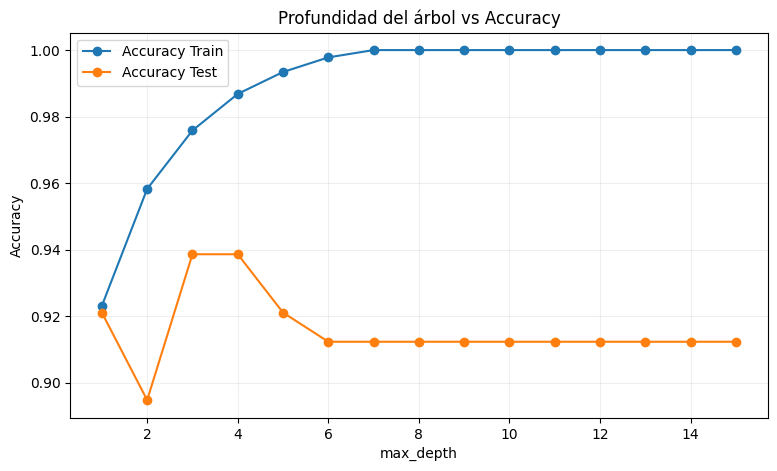

In [12]:

# Profundidad vs Accuracy / F1
profundidades = range(1, 16)

acc_train = []
acc_test = []
f1_train = []
f1_test = []

for depth in profundidades:
    modelo = DecisionTreeClassifier(
        max_depth=depth,
        random_state=RANDOM_STATE
    )

    modelo.fit(X_train, y_train)

    pred_train = modelo.predict(X_train)
    pred_test = modelo.predict(X_test)

    acc_train.append(accuracy_score(y_train, pred_train))
    acc_test.append(accuracy_score(y_test, pred_test))
    f1_train.append(f1_score(y_train, pred_train))
    f1_test.append(f1_score(y_test, pred_test))

plt.figure(figsize=(9,5))
plt.plot(list(profundidades), acc_train, marker="o", label="Accuracy Train")
plt.plot(list(profundidades), acc_test, marker="o", label="Accuracy Test")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Profundidad del árbol vs Accuracy")
plt.legend()
plt.grid(alpha=0.2)
plt.show()


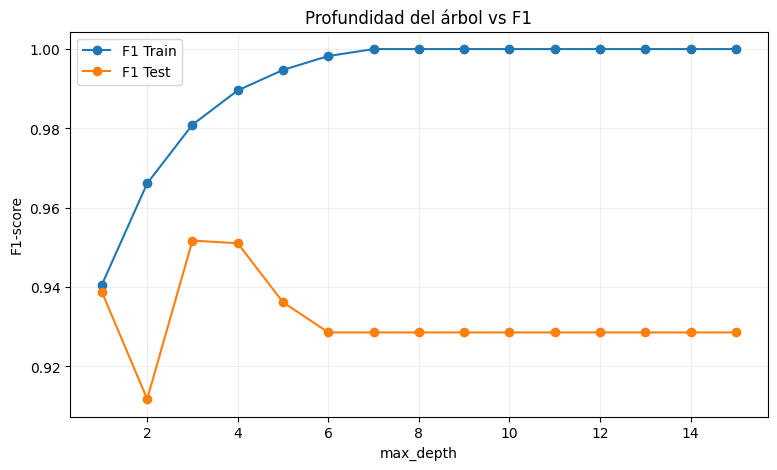

In [13]:

plt.figure(figsize=(9,5))
plt.plot(list(profundidades), f1_train, marker="o", label="F1 Train")
plt.plot(list(profundidades), f1_test, marker="o", label="F1 Test")
plt.xlabel("max_depth")
plt.ylabel("F1-score")
plt.title("Profundidad del árbol vs F1")
plt.legend()
plt.grid(alpha=0.2)
plt.show()



# 14. Hiperparámetros importantes

## `criterion`
- `gini`
- `entropy`

## `max_depth`
Profundidad máxima.

## `min_samples_split`
Mínimo de observaciones para dividir un nodo.

## `min_samples_leaf`
Mínimo de observaciones en una hoja.

## `max_features`
Número de variables consideradas en cada división.

## `ccp_alpha`
Controla la poda del árbol.

## `class_weight`
Permite dar más peso a una clase cuando existe desbalance.



# 15. Validación cruzada estratificada

En clasificación utilizaremos **StratifiedKFold**.

Esto conserva aproximadamente las proporciones de las clases dentro de cada fold.


In [14]:

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

scoring = {
    "Accuracy": "accuracy",
    "Precision": "precision",
    "Recall": "recall",
    "F1": "f1",
    "ROC_AUC": "roc_auc"
}

resultado_cv = cross_validate(
    modelo_baseline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

resumen_cv = pd.DataFrame({
    "Accuracy": resultado_cv["test_Accuracy"],
    "Precision": resultado_cv["test_Precision"],
    "Recall": resultado_cv["test_Recall"],
    "F1": resultado_cv["test_F1"],
    "ROC_AUC": resultado_cv["test_ROC_AUC"]
})

display(resumen_cv.round(4))

print("\nPromedios:")
display(resumen_cv.mean().to_frame("Promedio").T.round(4))


,Accuracy,Precision,Recall,F1,ROC_AUC
0,0.9231,0.9310,0.9474,0.9391,0.9616
1,0.9451,0.9815,0.9298,0.9550,0.9783
2,0.9121,0.9298,0.9298,0.9298,0.9404
3,0.9231,0.9167,0.9649,0.9402,0.9213
4,0.9560,0.9649,0.9649,0.9649,0.9814



Promedios:


,Accuracy,Precision,Recall,F1,ROC_AUC
Promedio,0.9319,0.9448,0.9474,0.9458,0.9566



# 16. Optimización con GridSearchCV

Usaremos como métrica principal:

**F1-score**

porque equilibra Precision y Recall.

También sería posible optimizar por:

- Recall;
- ROC-AUC;
- Accuracy;

dependiendo del objetivo real del proyecto.


In [15]:

modelo_grid = DecisionTreeClassifier(
    random_state=RANDOM_STATE
)

param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [2, 3, 4, 5, 6, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5, 10],
    "ccp_alpha": [0.0, 0.001, 0.01]
}

grid = GridSearchCV(
    estimator=modelo_grid,
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)

grid.fit(X_train, y_train)

print("Mejores hiperparámetros:")
print(grid.best_params_)

print("\nMejor F1 promedio de CV:")
print(round(grid.best_score_, 4))


Mejores hiperparámetros:
{'ccp_alpha': 0.0, 'criterion': 'entropy', 'max_depth': 4, 'min_samples_leaf': 5, 'min_samples_split': 2}

Mejor F1 promedio de CV:
0.9509


# 17. Evaluación final del mejor árbol

In [16]:

mejor_modelo = grid.best_estimator_

pred_train_final = mejor_modelo.predict(X_train)
pred_test_final = mejor_modelo.predict(X_test)

proba_train_final = mejor_modelo.predict_proba(X_train)[:, 1]
proba_test_final = mejor_modelo.predict_proba(X_test)[:, 1]

metricas_train_final = metricas_clasificacion(
    y_train,
    pred_train_final,
    proba_train_final
)

metricas_test_final = metricas_clasificacion(
    y_test,
    pred_test_final,
    proba_test_final
)

tabla_final = pd.DataFrame({
    "Train": metricas_train_final,
    "Test": metricas_test_final
}).T

display(tabla_final.round(4))


,Accuracy,Precision,Recall,Specificity,F1,ROC_AUC
Train,0.9736,0.9858,0.9719,0.9765,0.9788,0.9976
Test,0.8772,0.9531,0.8472,0.9286,0.8971,0.9593


In [17]:

comparacion_modelos = pd.DataFrame({
    "Baseline": metricas_test_baseline,
    "Optimizado": metricas_test_final
}).T

display(comparacion_modelos.round(4))


,Accuracy,Precision,Recall,Specificity,F1,ROC_AUC
Baseline,0.9211,0.9437,0.9306,0.9048,0.9371,0.9263
Optimizado,0.8772,0.9531,0.8472,0.9286,0.8971,0.9593


# 18. Matriz de confusión final

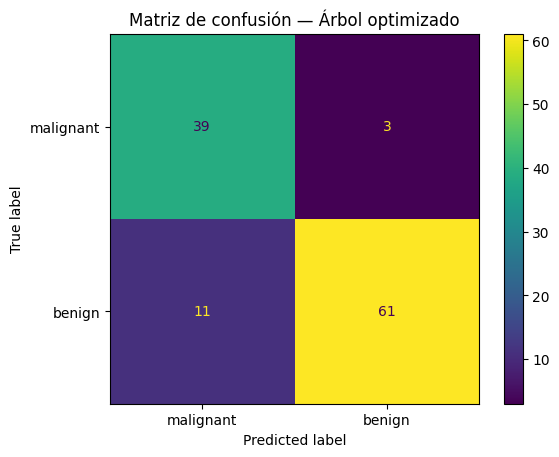

In [18]:

cm_final = confusion_matrix(y_test, pred_test_final)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_final,
    display_labels=data.target_names
)

disp.plot()
plt.title("Matriz de confusión — Árbol optimizado")
plt.show()


In [19]:

tn, fp, fn, tp = cm_final.ravel()

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)


True Negatives : 39
False Positives: 3
False Negatives: 11
True Positives : 61



# 19. Curva ROC

La curva ROC compara:

- **True Positive Rate (Recall)**
- **False Positive Rate**

para distintos umbrales de decisión.

El AUC resume la capacidad de discriminación.


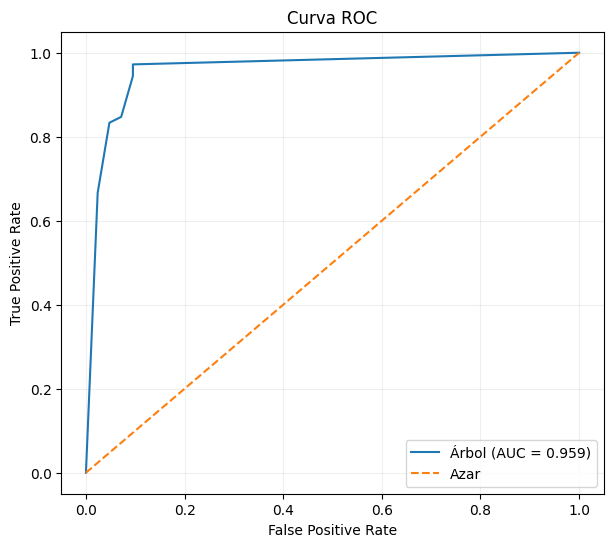

In [20]:

fpr, tpr, thresholds = roc_curve(
    y_test,
    proba_test_final
)

auc = roc_auc_score(
    y_test,
    proba_test_final
)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f"Árbol (AUC = {auc:.3f})")
plt.plot([0,1], [0,1], linestyle="--", label="Azar")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")
plt.legend()
plt.grid(alpha=0.2)
plt.show()



# 20. Curva Precision-Recall

Esta curva muestra cómo cambia Precision cuando intentamos aumentar Recall.

Es especialmente útil cuando existe desbalance de clases.


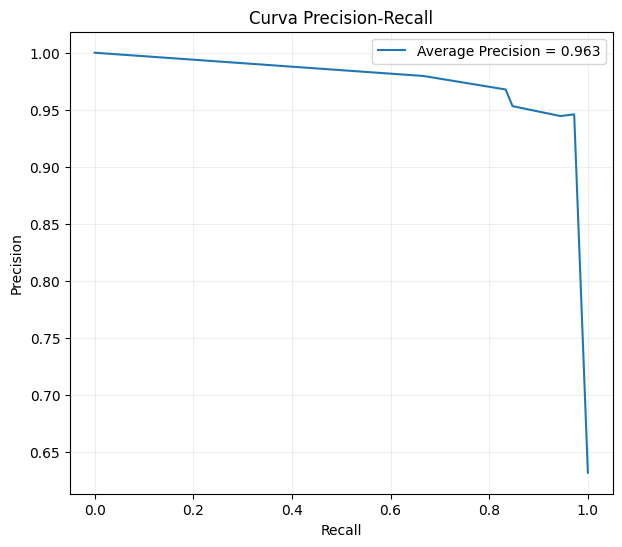

In [21]:

precision_curve, recall_curve, thresholds_pr = precision_recall_curve(
    y_test,
    proba_test_final
)

ap = average_precision_score(
    y_test,
    proba_test_final
)

plt.figure(figsize=(7,6))
plt.plot(
    recall_curve,
    precision_curve,
    label=f"Average Precision = {ap:.3f}"
)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall")
plt.legend()
plt.grid(alpha=0.2)
plt.show()



# 21. Predicción concreta de una observación

Tomaremos una observación real del conjunto Test.

Mostraremos:

- clase real;
- clase predicha;
- probabilidad estimada para cada clase.


In [22]:

posicion = 0

observacion = X_test.iloc[[posicion]]
valor_real = y_test.iloc[posicion]

clase_predicha = mejor_modelo.predict(observacion)[0]
probabilidades = mejor_modelo.predict_proba(observacion)[0]

print("CLASE REAL:")
print(data.target_names[valor_real])

print("\nCLASE PREDICHA:")
print(data.target_names[clase_predicha])

print("\nPROBABILIDADES:")
for clase, prob in zip(data.target_names, probabilidades):
    print(f"{clase}: {prob:.2%}")

print("\nVariables de la observación:")
display(observacion)


CLASE REAL:
malignant

CLASE PREDICHA:
malignant

PROBABILIDADES:
malignant: 100.00%
benign: 0.00%

Variables de la observación:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
256,19.55,28.77,133.6,1207.0,0.0926,0.2063,0.1784,0.1144,0.1893,0.06232,...,25.05,36.27,178.6,1926.0,0.1281,0.5329,0.4251,0.1941,0.2818,0.1005



# 22. Predicciones para varias observaciones

Ahora compararemos varias observaciones del Test.


In [23]:

n_ejemplos = min(15, len(X_test))

muestra_test = X_test.sample(
    n=n_ejemplos,
    random_state=RANDOM_STATE
)

real_muestra = y_test.loc[muestra_test.index]
pred_muestra = mejor_modelo.predict(muestra_test)
proba_muestra = mejor_modelo.predict_proba(muestra_test)[:, 1]

tabla_predicciones = pd.DataFrame({
    "Real": [
        data.target_names[i]
        for i in real_muestra.to_numpy()
    ],
    "Predicción": [
        data.target_names[i]
        for i in pred_muestra
    ],
    "Probabilidad_clase_1": proba_muestra
}, index=muestra_test.index)

tabla_predicciones["Correcta"] = (
    tabla_predicciones["Real"]
    == tabla_predicciones["Predicción"]
)

display(tabla_predicciones)


,Real,Predicción,Probabilidad_clase_1,Correcta
204,benign,benign,1.000000,True
564,malignant,malignant,0.000000,True
217,benign,benign,1.000000,True
496,benign,malignant,0.428571,False
292,benign,benign,1.000000,True
340,benign,malignant,0.428571,False
231,benign,benign,0.939394,True
291,benign,malignant,0.428571,False
206,benign,benign,1.000000,True
199,malignant,malignant,0.000000,True



# 23. ¿Qué tan bien está prediciendo?

En clasificación sí podemos hablar de porcentaje de aciertos:

$$
Accuracy = \frac{\text{Predicciones correctas}}{\text{Total}}
$$

Pero no debemos quedarnos únicamente con Accuracy.

También debemos preguntar:

- ¿cuántos positivos reales detecta?
- ¿cuántos positivos predichos son correctos?
- ¿cuántos negativos reconoce?
- ¿cuántos falsos negativos produce?


In [24]:

aciertos = (pred_test_final == y_test.to_numpy())

tabla_aciertos = pd.DataFrame({
    "Resultado": ["Correctas", "Incorrectas"],
    "Cantidad": [
        aciertos.sum(),
        (~aciertos).sum()
    ]
})

display(tabla_aciertos)


,Resultado,Cantidad
0,Correctas,100
1,Incorrectas,14


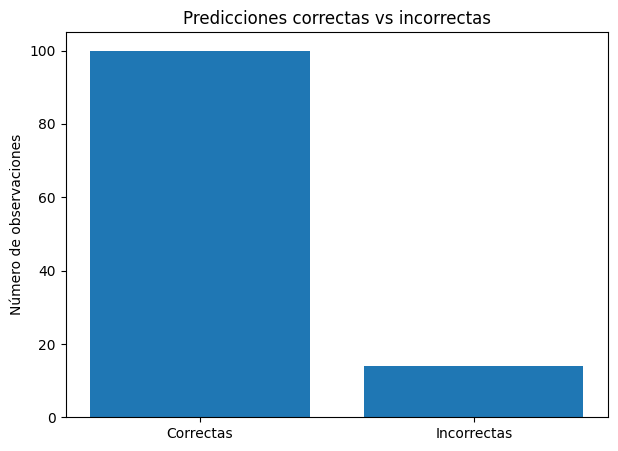

In [25]:

plt.figure(figsize=(7,5))
plt.bar(
    tabla_aciertos["Resultado"],
    tabla_aciertos["Cantidad"]
)
plt.title("Predicciones correctas vs incorrectas")
plt.ylabel("Número de observaciones")
plt.show()



# 24. Importancia de variables

El Árbol puede estimar qué variables utilizó más para reducir impureza.

> Esto representa importancia predictiva, no causalidad.


In [26]:

importancias = pd.Series(
    mejor_modelo.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

display(importancias.head(15).to_frame("Importancia"))


,Importancia
worst radius,0.643902
worst concave points,0.163313
texture error,0.072406
worst texture,0.044239
worst concavity,0.040667
area error,0.023295
worst area,0.012177
mean compactness,0.000000
mean concavity,0.000000
mean smoothness,0.000000


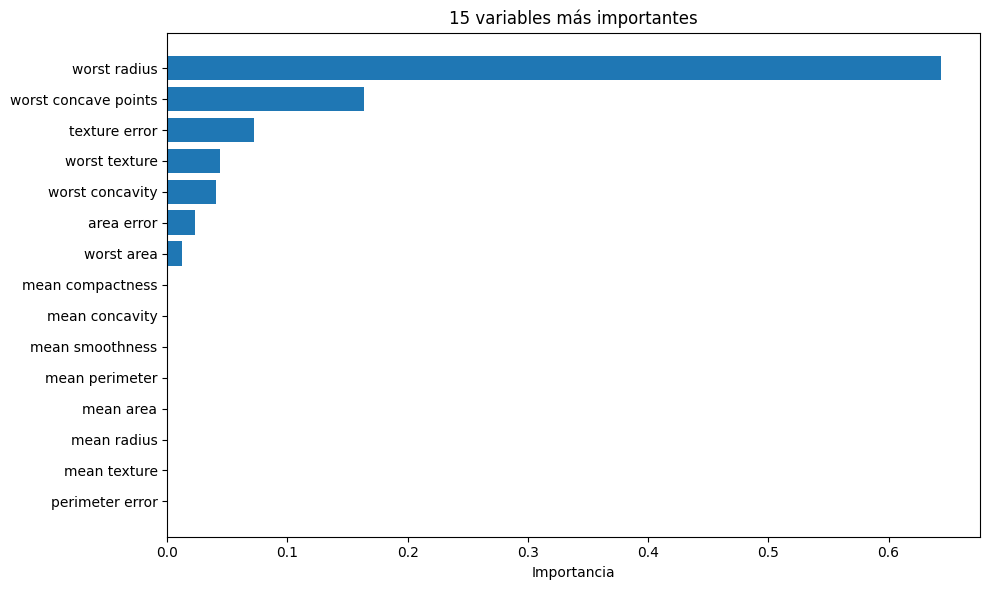

In [27]:

top_importancias = importancias.head(15)

plt.figure(figsize=(10,6))
plt.barh(
    top_importancias.index[::-1],
    top_importancias.values[::-1]
)
plt.title("15 variables más importantes")
plt.xlabel("Importancia")
plt.tight_layout()
plt.show()


# 25. Visualización del árbol

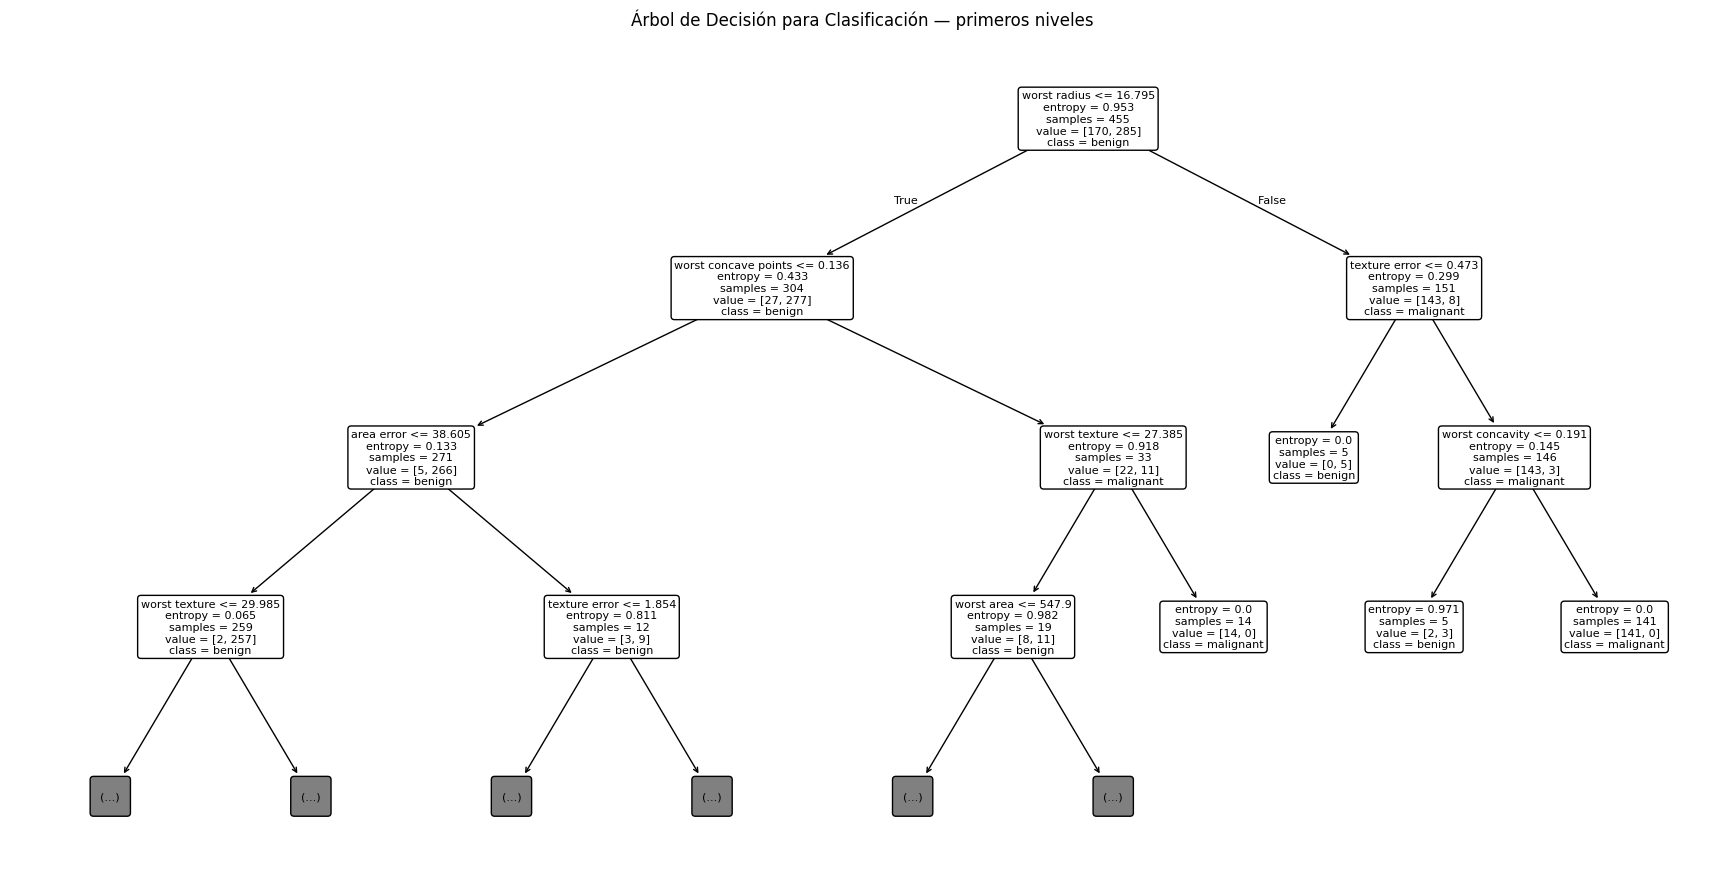

In [28]:

plt.figure(figsize=(22,11))

plot_tree(
    mejor_modelo,
    feature_names=X.columns,
    class_names=data.target_names,
    filled=False,
    rounded=True,
    max_depth=3,
    fontsize=8
)

plt.title("Árbol de Decisión para Clasificación — primeros niveles")
plt.show()



# 26. ¿Cómo leer un nodo?

Un nodo puede mostrar:

- variable utilizada;
- punto de corte;
- criterio de impureza;
- número de observaciones;
- distribución de clases;
- clase predominante.

Ejemplo conceptual:

`worst radius <= 16.8`

Si la condición se cumple, seguimos una rama.

Si no, seguimos la otra.

El proceso continúa hasta llegar a una hoja.



# 27. ¿Cómo se usa en la vida real?

## Fraude
- X: monto, hora, país, dispositivo
- y: fraude / no fraude

## Marketing
- X: compras, visitas, frecuencia
- y: compra / no compra

## Crédito
- X: ingresos, deuda, historial
- y: aprobado / rechazado

## Industria
- X: sensores, temperatura, vibración
- y: falla / no falla

## Salud
- X: variables clínicas
- y: clase diagnóstica

En todos los casos es fundamental analizar el costo de FP y FN.



# 28. ¿Cuándo conviene un Árbol de Clasificación?

Puede ser útil cuando:

- queremos reglas interpretables;
- existen relaciones no lineales;
- hay interacciones;
- necesitamos un baseline fácil de explicar;
- queremos visualizar decisiones.

Puede no ser suficiente cuando:

- necesitamos máxima estabilidad;
- hay mucho ruido;
- pequeñas variaciones cambian mucho el árbol.

En esos casos podemos comparar con:

- Random Forest;
- Gradient Boosting;
- XGBoost;
- LightGBM;
- CatBoost.



# 29. Métrica recomendada según el objetivo

## Clases balanceadas y costos similares
**Accuracy**

## Falsos positivos costosos
**Precision**

## Falsos negativos costosos
**Recall**

## Necesitamos equilibrio
**F1**

## Evaluación global de discriminación
**ROC-AUC**

## Clases muy desbalanceadas
Matriz de confusión + Recall + Precision + F1 + Precision-Recall curve.

La métrica debe seleccionarse según el problema, no por costumbre.



# 30. Errores comunes

1. Usar solo Accuracy.
2. Ignorar el desbalance.
3. No usar `stratify`.
4. Entrenar y evaluar con los mismos datos.
5. Dejar crecer el árbol sin control.
6. Optimizar hiperparámetros mirando Test.
7. No analizar FP y FN.
8. Interpretar importancia como causalidad.
9. Confundir probabilidad con certeza.
10. Usar un modelo académico como herramienta clínica.



# 31. Flujo recomendado

**Problema → definir clases → EDA → revisar balance → X/y → Train/Test estratificado → baseline → matriz de confusión → métricas → Train vs Test → validación cruzada → GridSearchCV → Test final → ROC → Precision-Recall → predicciones → importancia → interpretación**



# 32. Conclusión

En este notebook aprendimos que un Árbol de Decisión para Clasificación:

- divide el espacio mediante reglas;
- utiliza Gini o Entropía;
- devuelve clases y probabilidades;
- puede evaluarse con múltiples métricas;
- requiere especial atención a FP y FN;
- puede sobreajustarse;
- debe optimizarse usando validación cruzada;
- es muy interpretable;
- no debe juzgarse únicamente por Accuracy.

La pregunta correcta no es:

> “¿Cuántas predicciones acertó?”

sino:

> **“¿Qué tipo de errores está cometiendo y qué tan importantes son para este problema?”**



# 33. Referencias

- Scikit-learn — DecisionTreeClassifier  
  https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html

- Scikit-learn — Breast Cancer Wisconsin dataset  
  https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html

- Scikit-learn — Classification metrics  
  https://scikit-learn.org/stable/modules/model_evaluation.html#classification-metrics

- Scikit-learn — Decision Trees  
  https://scikit-learn.org/stable/modules/tree.html
